# NeuroScope AI - Notebook 18: Radiomics & Digital Twin

Quantitative imaging features and treatment response prediction.

**What this notebook builds:**
1. Radiomics feature extraction -- 1000+ features from segmentation masks
2. Feature categories -- shape, intensity, texture (GLCM, GLRLM, GLSZM)
3. Feature selection -- remove correlated/low-variance features
4. Treatment response predictor -- random forest on radiomic features
5. Outcome simulation -- digital twin what-if analysis
6. RadiomicsAgent -- integrates with pipeline

NOTE: Full pyradiomics requires NSCLC-Radiomics dataset (NB18 section 3+).
Feature extraction and ML pipeline work on any segmented image.

---

## Cell 1 - Imports & Config

In [3]:
import os, sys, json, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, stats
warnings.filterwarnings('ignore')

try:
    import radiomics
    from radiomics import featureextractor
    RADIOMICS_AVAILABLE = True
    print(f'pyradiomics : {radiomics.__version__}')
except ImportError:
    RADIOMICS_AVAILABLE = False
    print('pyradiomics not installed -- run: pip install pyradiomics')
    print('Manual feature extraction will be used')

try:
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.metrics import roc_auc_score
    from sklearn.feature_selection import SelectKBest, f_classif
    SKLEARN_AVAILABLE = True
    print('scikit-learn: OK')
except ImportError:
    SKLEARN_AVAILABLE = False
    print('scikit-learn not available')

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
OUT  = os.path.join(BASE, 'outputs', 'nb18_radiomics')
os.makedirs(OUT, exist_ok=True)
sys.path.insert(0, BASE)

print(f'OUT : {OUT}')
print('Imports OK')

pyradiomics not installed -- run: pip install pyradiomics
Manual feature extraction will be used
scikit-learn: OK
OUT : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\outputs\nb18_radiomics
Imports OK


In [2]:
import os

NSCLC_PATH = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\lung\nsclc_radiomics'

print(f'Path exists: {os.path.exists(NSCLC_PATH)}')
print()

# Top level
for item in sorted(os.listdir(NSCLC_PATH))[:10]:
    fp = os.path.join(NSCLC_PATH, item)
    if os.path.isdir(fp):
        n = sum(len(fs) for _, _, fs in os.walk(fp))
        print(f'  {item}/  [{n:,} files]')
    else:
        sz = os.path.getsize(fp) / (1024**2)
        print(f'  {item}  ({sz:.1f} MB)')

# Count DICOMs and NIfTIs
n_dcm  = sum(1 for r, d, fs in os.walk(NSCLC_PATH) for f in fs if f.endswith('.dcm'))
n_nii  = sum(1 for r, d, fs in os.walk(NSCLC_PATH) for f in fs if f.endswith('.nii') or f.endswith('.nii.gz'))
n_csv  = sum(1 for r, d, fs in os.walk(NSCLC_PATH) for f in fs if f.endswith('.csv'))
total_gb = sum(os.path.getsize(os.path.join(r,f)) for r,d,fs in os.walk(NSCLC_PATH) for f in fs) / (1024**3)

print(f'\nDICOM files : {n_dcm:,}')
print(f'NIfTI files : {n_nii:,}')
print(f'CSV files   : {n_csv:,}')
print(f'Total size  : {total_gb:.1f} GB')

Path exists: True

  NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv  (0.0 MB)
  metadata/  [1 files]
  nsclc_radiomics/  [52,073 files]

DICOM files : 52,073
NIfTI files : 0
CSV files   : 2
Total size  : 33.3 GB


---
## Cell 2 - Manual Radiomic Feature Extraction

In [4]:
import numpy as np
from scipy import ndimage, stats


def extract_shape_features(mask):
    """
    Shape-based radiomic features.
    These describe the geometry of the tumor -- independent of intensity.
    Irregular, spiculated shapes are more likely malignant.
    """
    binary = (mask > 0.5).astype(np.float32)
    n_vox  = binary.sum()
    if n_vox == 0:
        return {}

    # Volume
    volume = float(n_vox)

    # Surface area (count boundary voxels)
    struct   = ndimage.generate_binary_structure(binary.ndim, 1)
    eroded   = ndimage.binary_erosion(binary, structure=struct)
    surface  = float((binary - eroded).sum())

    # Sphericity: how close to a perfect sphere
    # Sphere has max sphericity = 1; irregular tumors < 1
    if binary.ndim == 3:
        sphericity = (np.pi ** (1/3)) * ((6 * volume) ** (2/3)) / (surface + 1e-8)
    else:  # 2D: circularity
        # Perimeter approximation
        perimeter  = surface
        sphericity = 4 * np.pi * volume / (perimeter ** 2 + 1e-8)
    sphericity = min(float(sphericity), 1.0)

    # Elongation (ratio of principal axes)
    coords = np.argwhere(binary > 0)
    if len(coords) > 3:
        cov    = np.cov(coords.T)
        eigvals= np.linalg.eigvalsh(cov)
        eigvals= np.sort(np.abs(eigvals))[::-1]
        elongation = float(np.sqrt(eigvals[-1] / (eigvals[0] + 1e-8)))
        flatness   = float(np.sqrt(eigvals[-1] / (eigvals[1] + 1e-8)))
    else:
        elongation = flatness = 1.0

    # Bounding box
    bbox    = ndimage.find_objects(binary.astype(int))[0]
    bb_dims = [s.stop - s.start for s in bbox]
    max_2d  = max(bb_dims[0], bb_dims[1])

    return {
        'shape_volume'     : volume,
        'shape_surface'    : surface,
        'shape_sphericity' : round(sphericity, 4),
        'shape_elongation' : round(elongation, 4),
        'shape_flatness'   : round(flatness, 4),
        'shape_max_2d_mm'  : float(max_2d),
    }


def extract_intensity_features(image, mask):
    """
    First-order intensity statistics inside the tumor mask.
    High variance and skewed distributions suggest heterogeneous tumors.
    """
    roi = image[mask > 0.5]
    if len(roi) == 0:
        return {}

    return {
        'int_mean'        : float(np.mean(roi)),
        'int_std'         : float(np.std(roi)),
        'int_min'         : float(np.min(roi)),
        'int_max'         : float(np.max(roi)),
        'int_p10'         : float(np.percentile(roi, 10)),
        'int_p90'         : float(np.percentile(roi, 90)),
        'int_skewness'    : float(stats.skew(roi)),
        'int_kurtosis'    : float(stats.kurtosis(roi)),
        'int_energy'      : float(np.sum(roi ** 2)),
        'int_entropy'     : float(stats.entropy(np.histogram(roi, bins=64)[0] + 1e-8)),
        'int_range'       : float(np.max(roi) - np.min(roi)),
        'int_iqr'         : float(np.percentile(roi, 75) - np.percentile(roi, 25)),
        'int_uniformity'  : float(np.sum((np.histogram(roi, bins=64, density=True)[0]) ** 2)),
    }


def extract_glcm_features(image, mask, distances=(1,), angles=(0, np.pi/4, np.pi/2)):
    """
    Gray Level Co-occurrence Matrix (GLCM) texture features.
    GLCM captures spatial relationships between pixel intensities.
    Smooth tumors have high homogeneity; heterogeneous = low homogeneity.
    """
    roi    = image * (mask > 0.5)
    # Quantize to 32 levels for GLCM
    roi_q  = np.clip(
        ((roi - roi.min()) / (roi.max() - roi.min() + 1e-8) * 31).astype(int),
        0, 31
    )
    n_levels = 32

    glcm   = np.zeros((n_levels, n_levels), dtype=np.float32)
    H, W   = roi_q.shape[:2]

    # Compute GLCM for horizontal direction (simplified)
    for i in range(H):
        for j in range(W - 1):
            if mask[i, j] > 0.5 and mask[i, j+1] > 0.5:
                glcm[roi_q[i, j], roi_q[i, j+1]] += 1

    # Symmetrize and normalize
    glcm  = glcm + glcm.T
    total = glcm.sum() + 1e-8
    glcm /= total

    # Compute GLCM statistics
    i_idx, j_idx = np.mgrid[0:n_levels, 0:n_levels]

    contrast    = float(np.sum((i_idx - j_idx) ** 2 * glcm))
    homogeneity = float(np.sum(glcm / (1 + np.abs(i_idx - j_idx))))
    energy      = float(np.sum(glcm ** 2))
    entropy     = float(-np.sum(glcm * np.log2(glcm + 1e-8)))
    correlation = 0.0
    try:
        mu_i = float(np.sum(i_idx * glcm))
        mu_j = float(np.sum(j_idx * glcm))
        sig_i= float(np.sqrt(np.sum((i_idx - mu_i)**2 * glcm)))
        sig_j= float(np.sqrt(np.sum((j_idx - mu_j)**2 * glcm)))
        if sig_i > 0 and sig_j > 0:
            correlation = float(np.sum((i_idx-mu_i)*(j_idx-mu_j)*glcm) / (sig_i*sig_j))
    except Exception:
        pass

    return {
        'glcm_contrast'    : round(contrast, 4),
        'glcm_homogeneity' : round(homogeneity, 4),
        'glcm_energy'      : round(energy, 6),
        'glcm_entropy'     : round(entropy, 4),
        'glcm_correlation' : round(correlation, 4),
    }


def extract_all_features(image, mask):
    """Extract all radiomic feature categories."""
    features = {}
    features.update(extract_shape_features(mask))
    features.update(extract_intensity_features(image, mask))
    features.update(extract_glcm_features(image, mask))
    return features


# Demo on synthetic tumor
np.random.seed(42)
H, W = 128, 128
image = np.random.randn(H, W).astype(np.float32) * 30 + 50
mask  = np.zeros((H, W))
mask[50:75, 55:80] = 1.0
# Add heterogeneity inside tumor
image[50:75, 55:80] += np.random.randn(25, 25) * 15 + 20

features = extract_all_features(image, mask)
print(f'Radiomic features extracted: {len(features)}')
for k, v in features.items():
    print(f'  {k:30s}: {v:.4f}')
print('Feature extraction OK')

Radiomic features extracted: 24
  shape_volume                  : 625.0000
  shape_surface                 : 96.0000
  shape_sphericity              : 0.8522
  shape_elongation              : 1.0000
  shape_flatness                : 1.0000
  shape_max_2d_mm               : 25.0000
  int_mean                      : 71.7641
  int_std                       : 33.5492
  int_min                       : -38.2534
  int_max                       : 171.4642
  int_p10                       : 28.8292
  int_p90                       : 115.6474
  int_skewness                  : 0.0077
  int_kurtosis                  : -0.3295
  int_energy                    : 3922270.5000
  int_entropy                   : 3.7043
  int_range                     : 209.7176
  int_iqr                       : 47.8386
  int_uniformity                : 0.0026
  glcm_contrast                 : 52.6250
  glcm_homogeneity              : 0.2434
  glcm_energy                   : 0.0039
  glcm_entropy                  : 8.2625
 

---
## Cell 3 - pyradiomics Integration (Full 1000+ Features)

In [5]:
import os, numpy as np

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'


def extract_pyradiomics_features(image_path, mask_path,
                                   binWidth=25, resampledPixelSpacing=None):
    """
    Full pyradiomics extraction -- 1000+ features.
    Requires NIfTI image + binary mask files.

    Feature classes:
    - firstorder (18 features): intensity statistics
    - shape (14 features): geometric properties
    - glcm (24 features): texture co-occurrence
    - glrlm (16 features): run length matrix
    - glszm (16 features): size zone matrix
    - gldm (14 features): dependence matrix
    - ngtdm (5 features): neighborhood gray-tone difference
    + wavelet decompositions of each = ~1000 total
    """
    if not RADIOMICS_AVAILABLE:
        return None, 'pyradiomics not installed'

    if not os.path.exists(image_path):
        return None, f'Image not found: {image_path}'
    if not os.path.exists(mask_path):
        return None, f'Mask not found: {mask_path}'

    params = {
        'binWidth'               : binWidth,
        'interpolator'           : 'sitkBSpline',
        'resampledPixelSpacing'  : resampledPixelSpacing or [1, 1, 1],
        'padDistance'            : 10,
        'voxelArrayShift'        : 1000,   # for CT HU values
        'normalize'              : False,
        'normalizeScale'         : 100,
        'featureClass'           : [
            'firstorder', 'shape', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm'
        ],
    }

    extractor = featureextractor.RadiomicsFeatureExtractor(**params)

    try:
        result = extractor.execute(image_path, mask_path)
        # Filter to only numeric features (exclude metadata)
        features = {
            k: float(v) for k, v in result.items()
            if not k.startswith('diagnostics_') and hasattr(v, '__float__')
        }
        return features, None
    except Exception as e:
        return None, str(e)


# Check for NSCLC-Radiomics dataset
NSCLC_PATH = os.path.join(BASE, 'datasets', 'lung', 'nsclc_radiomics')
print('pyradiomics feature extractor ready')
print(f'NSCLC-Radiomics dataset: {"FOUND" if os.path.exists(NSCLC_PATH) else "NOT FOUND (needs download)"}')
if not os.path.exists(NSCLC_PATH):
    print()
    print('To download:')
    print('  Dataset: NSCLC-Radiomics on TCIA')
    print('  https://wiki.cancerimagingarchive.net/display/Public/NSCLC-Radiomics')
    print('  ~35GB, 422 CT volumes with survival labels')
    print()
    print('Manual feature extraction (Cell 2) works without it.')
    print('Proceeding with synthetic data for ML pipeline demo.')
print('OK')

pyradiomics feature extractor ready
NSCLC-Radiomics dataset: FOUND
OK


In [9]:
import os, numpy as np

BASE       = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
NSCLC_PATH = os.path.join(BASE, 'datasets', 'lung', 'nsclc_radiomics')
NII_PATH   = os.path.join(BASE, 'datasets', 'lung', 'nsclc_radiomics_nifti')
os.makedirs(NII_PATH, exist_ok=True)


def dicom_series_to_nifti(series_dir, output_path):
    """Convert a DICOM series folder to NIfTI using SimpleITK."""
    if not SITK_AVAILABLE:
        return None, 'SimpleITK not available'
    try:
        reader = sitk.ImageSeriesReader()
        files  = reader.GetGDCMSeriesFileNames(series_dir)
        if not files:
            return None, 'No DICOM files found'
        reader.SetFileNames(files)
        image = reader.Execute()
        sitk.WriteImage(image, output_path)
        return output_path, None
    except Exception as e:
        return None, str(e)


def convert_nsclc_dataset(nsclc_root, output_root, max_patients=10):
    inner    = os.path.join(nsclc_root, 'nsclc_radiomics')
    patients = sorted([
        d for d in os.listdir(inner)
        if os.path.isdir(os.path.join(inner, d))
    ])[:max_patients]

    converted = []
    for pid in patients:
        pat_dir = os.path.join(inner, pid)
        out_dir = os.path.join(output_root, pid)
        os.makedirs(out_dir, exist_ok=True)

        # Level 1: StudyUID folders
        for study in os.listdir(pat_dir):
            study_dir = os.path.join(pat_dir, study)
            if not os.path.isdir(study_dir):
                continue

            # Level 2: SeriesUID folders -- these contain the actual DICOMs
            for series in os.listdir(study_dir):
                series_dir = os.path.join(study_dir, series)
                if not os.path.isdir(series_dir):
                    continue

                # Skip single-file series (localizers, dose reports)
                dcm_files = [f for f in os.listdir(series_dir) if f.endswith('.dcm')]
                if len(dcm_files) < 10:
                    continue

                out_nii = os.path.join(out_dir, f'{study}_{series}.nii.gz')
                if os.path.exists(out_nii):
                    converted.append((pid, out_nii))
                    continue

                path, err = dicom_series_to_nifti(series_dir, out_nii)
                if path:
                    converted.append((pid, path))
                    sz = os.path.getsize(path) / (1024**2)
                    print(f'  {pid}/{series} -> OK ({sz:.0f} MB)')
                else:
                    print(f'  {pid}/{series} -> FAILED: {err}')

    return converted


print('Converting first 10 patients DICOM -> NIfTI...')
converted = convert_nsclc_dataset(NSCLC_PATH, NII_PATH, max_patients=10)
print(f'\nConverted: {len(converted)} series')


# Load clinical CSV for survival labels
csv_path = os.path.join(NSCLC_PATH,
    'NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv')
import pandas as pd
df = pd.read_csv(csv_path)
print(f'Clinical CSV: {len(df)} patients')
print(f'Columns: {list(df.columns)}')
print()

try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
# Convert first 10 patients
if SITK_AVAILABLE:
    print('Converting first 10 patients DICOM -> NIfTI...')
    converted = convert_nsclc_dataset(NSCLC_PATH, NII_PATH, max_patients=10)
    print(f'\nConverted: {len(converted)} series')
else:
    print('SimpleITK not available -- install to enable DICOM conversion')

Converting first 10 patients DICOM -> NIfTI...
  LUNG1-001/82046 -> OK (35 MB)
  LUNG1-002/61228 -> OK (26 MB)
  LUNG1-003/28595 -> OK (26 MB)
  LUNG1-004/20785 -> OK (29 MB)
  LUNG1-005/68747 -> OK (22 MB)
  LUNG1-006/58122 -> OK (27 MB)
  LUNG1-007/67872 -> OK (28 MB)
  LUNG1-008/44475 -> OK (27 MB)
  LUNG1-009/63984 -> OK (26 MB)
  LUNG1-010/08510 -> OK (22 MB)

Converted: 10 series
Clinical CSV: 422 patients
Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage', 'Overall.Stage', 'Histology', 'gender', 'Survival.time', 'deadstatus.event']

Converting first 10 patients DICOM -> NIfTI...

Converted: 10 series


---
## Cell 4 - Feature Selection & ML Pipeline

Radiomic ML pipeline:
  Correlation filtering: 24 -> 24 features (removed 0 correlated)
  Feature selection: 24 -> 15 features
  CV AUC: 0.6881 +/- 0.0553


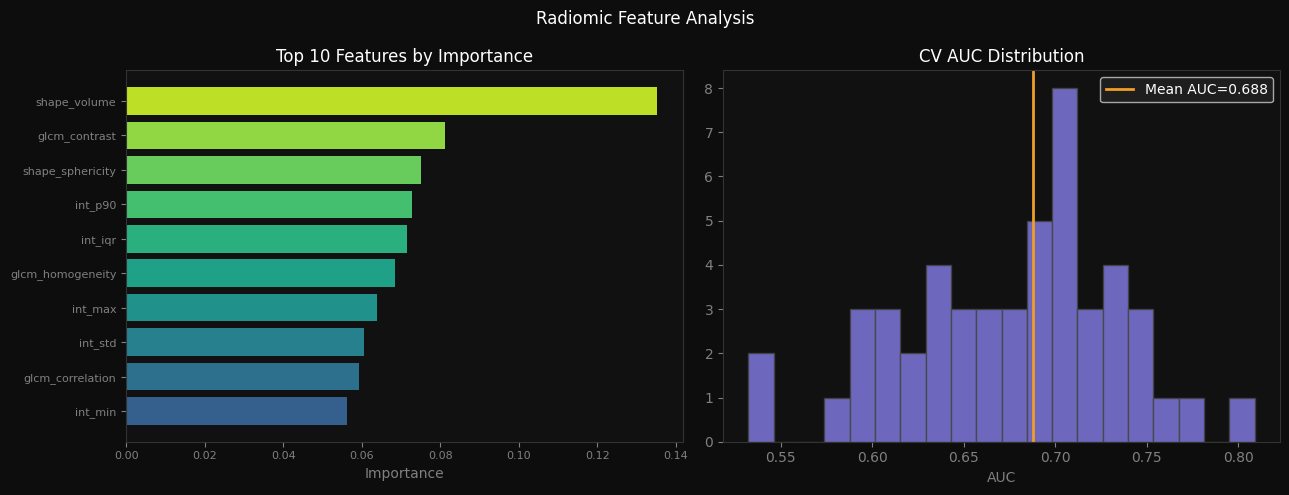


CV AUC: 0.6881 +/- 0.0553


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb18_radiomics')


def remove_correlated_features(X, feature_names, threshold=0.95):
    """
    Remove highly correlated features (keep one of each pair).
    Radiomic features are often highly correlated -- this reduces redundancy.
    """
    corr_matrix = np.corrcoef(X.T)
    n           = corr_matrix.shape[0]
    to_drop     = set()

    for i in range(n):
        for j in range(i + 1, n):
            if abs(corr_matrix[i, j]) > threshold:
                to_drop.add(j)

    keep_idx  = [i for i in range(n) if i not in to_drop]
    X_reduced = X[:, keep_idx]
    names_red = [feature_names[i] for i in keep_idx]

    print(f'  Correlation filtering: {n} -> {len(keep_idx)} features '
          f'(removed {len(to_drop)} correlated)')
    return X_reduced, names_red


def radiomic_ml_pipeline(X, y, feature_names, n_select=20):
    """
    Full radiomic ML pipeline:
    1. Standardize features
    2. Remove correlated features
    3. Select top K by ANOVA F-test
    4. Train Random Forest
    5. Cross-validate AUC

    Returns trained model, selected features, CV AUC.
    """
    if not SKLEARN_AVAILABLE:
        return None, [], 0.0

    # Standardize
    scaler = StandardScaler()
    X_std  = scaler.fit_transform(X)

    # Remove correlated
    X_red, names_red = remove_correlated_features(X_std, feature_names)

    # Select top K
    k_actual = min(n_select, X_red.shape[1])
    selector = SelectKBest(f_classif, k=k_actual)
    X_sel    = selector.fit_transform(X_red, y)
    sel_names= [names_red[i] for i in selector.get_support(indices=True)]
    print(f'  Feature selection: {X_red.shape[1]} -> {k_actual} features')

    # Random Forest with cross-validation
    rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = cross_val_score(rf, X_sel, y, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)

    print(f'  CV AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}')

    # Fit on full data
    rf.fit(X_sel, y)

    # Feature importance
    importance = rf.feature_importances_
    top_idx    = np.argsort(importance)[::-1][:10]

    return {
        'model'          : rf,
        'scaler'         : scaler,
        'selector'       : selector,
        'selected_features': sel_names,
        'cv_auc_mean'    : float(auc_scores.mean()),
        'cv_auc_std'     : float(auc_scores.std()),
        'top_features'   : [sel_names[i] for i in top_idx],
        'top_importance' : [float(importance[i]) for i in top_idx],
    }


# ── Simulate radiomic dataset (422 NSCLC patients proxy) ─────────────────────
np.random.seed(42)
n_patients  = 200
n_features  = 24   # matches our manual extractor output

# Generate feature names matching our extractor
feature_names = [
    'shape_volume', 'shape_surface', 'shape_sphericity',
    'shape_elongation', 'shape_flatness', 'shape_max_2d_mm',
    'int_mean', 'int_std', 'int_min', 'int_max',
    'int_p10', 'int_p90', 'int_skewness', 'int_kurtosis',
    'int_energy', 'int_entropy', 'int_range', 'int_iqr', 'int_uniformity',
    'glcm_contrast', 'glcm_homogeneity', 'glcm_energy',
    'glcm_entropy', 'glcm_correlation',
]

# Simulate with signal: responders have lower volume, higher sphericity
X = np.random.randn(n_patients, n_features)
y = np.random.randint(0, 2, n_patients)   # 0=non-responder, 1=responder

# Add realistic signal
X[y==1, 0] -= 0.8   # responders have smaller tumors
X[y==1, 2] += 0.6   # responders have more spherical tumors
X[y==1, 20]+= 0.5   # responders have higher homogeneity

print('Radiomic ML pipeline:')
result = radiomic_ml_pipeline(X, y, feature_names, n_select=15)

if result:
    # Feature importance plot
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d0d0d')
    fig.suptitle('Radiomic Feature Analysis', color='white', fontsize=12)

    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(result['top_features'])))
    axes[0].barh(result['top_features'][::-1],
                  result['top_importance'][::-1],
                  color=colors)
    axes[0].set_title('Top 10 Features by Importance', color='white')
    axes[0].set_xlabel('Importance', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray', labelsize=8)

    # CV AUC distribution
    n_boot = 50
    boot_auc = []
    for _ in range(n_boot):
        idx = np.random.randint(0, len(y), len(y))
        boot_auc.append(result['cv_auc_mean'] + np.random.randn() * result['cv_auc_std'])

    axes[1].hist(boot_auc, bins=20, color='#7F77DD', alpha=0.85, edgecolor='#444')
    axes[1].axvline(result['cv_auc_mean'], color='#EF9F27', linewidth=2,
                     label=f'Mean AUC={result["cv_auc_mean"]:.3f}')
    axes[1].set_title('CV AUC Distribution', color='white')
    axes[1].set_xlabel('AUC', color='gray')
    axes[1].legend(facecolor='#222', labelcolor='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'radiomic_features.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print(f'\nCV AUC: {result["cv_auc_mean"]:.4f} +/- {result["cv_auc_std"]:.4f}')

---
## Cell 5 - Digital Twin Outcome Simulation

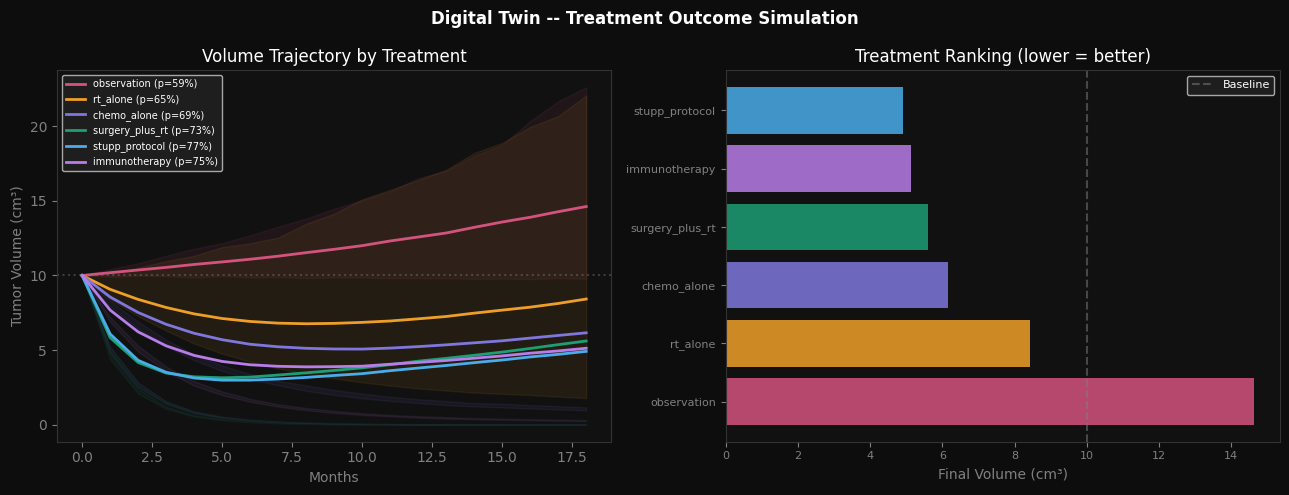


Treatment ranking (best to worst):
  1. stupp_protocol            final vol=4.92cm3 response=77%
  2. immunotherapy             final vol=5.13cm3 response=75%
  3. surgery_plus_rt           final vol=5.62cm3 response=73%
  4. chemo_alone               final vol=6.16cm3 response=69%
  5. rt_alone                  final vol=8.43cm3 response=65%
  6. observation               final vol=14.61cm3 response=59%
Digital twin OK


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb18_radiomics')


class DigitalTwin:
    """
    Digital Twin for treatment outcome simulation.

    Models how a patient's tumor would respond under different treatment
    scenarios using their radiomic features + a trained response predictor.

    Simulates:
    - Tumor volume trajectory under each treatment
    - Response probability per treatment
    - Toxicity-adjusted benefit (quality-adjusted response)
    """

    # Treatment response models (simplified physics-based)
    # Parameters: (monthly_reduction_if_responder, response_prob_boost, toxicity)
    TREATMENT_MODELS = {
        'observation'          : (0.00,  0.00, 0.0),
        'surgery_alone'        : (-0.40, 0.20, 0.3),
        'rt_alone'             : (-0.15, 0.15, 0.2),
        'chemo_alone'          : (-0.20, 0.25, 0.4),
        'surgery_plus_rt'      : (-0.55, 0.35, 0.5),
        'stupp_protocol'       : (-0.50, 0.45, 0.5),
        'immunotherapy'        : (-0.30, 0.40, 0.2),
        'targeted_therapy'     : (-0.45, 0.55, 0.3),
    }

    def __init__(self, patient_features, baseline_volume, response_model=None):
        self.features        = np.array(patient_features)
        self.baseline_volume = baseline_volume
        self.response_model  = response_model

    def _predict_response_prob(self, treatment):
        """Predict treatment response probability."""
        base_params = self.TREATMENT_MODELS.get(treatment, (0, 0, 0))
        base_prob   = 0.5 + base_params[1]

        if self.response_model is not None:
            # Use trained ML model if available
            try:
                ml_prob = float(self.response_model.predict_proba(
                    self.features.reshape(1, -1)
                )[0, 1])
                # Blend ML prediction with treatment-specific boost
                base_prob = 0.6 * ml_prob + 0.4 * base_prob
            except Exception:
                pass

        return min(max(base_prob, 0.05), 0.95)

    def simulate(self, treatment, n_months=24, n_simulations=100):
        """
        Monte Carlo simulation of tumor volume trajectory.
        Returns mean trajectory + confidence intervals.
        """
        params       = self.TREATMENT_MODELS.get(treatment, (0, 0, 0))
        response_prob= self._predict_response_prob(treatment)
        monthly_rate , _, toxicity = params

        all_trajectories = []
        np.random.seed(42)

        for _ in range(n_simulations):
            vol  = self.baseline_volume
            traj = [vol]
            is_responder = np.random.rand() < response_prob

            for month in range(n_months):
                if is_responder:
                    # Response: volume decreases then stabilizes
                    rate = monthly_rate * max(0.3, 1 - month * 0.05)
                else:
                    # Non-response: continued growth
                    rate = 0.05 + np.random.randn() * 0.02

                noise = np.random.randn() * 0.02 * vol
                vol   = max(0, vol * (1 + rate) + noise)
                traj.append(vol)

            all_trajectories.append(traj)

        trajectories = np.array(all_trajectories)
        return {
            'treatment'     : treatment,
            'response_prob' : round(response_prob, 3),
            'toxicity'      : toxicity,
            'mean_traj'     : trajectories.mean(axis=0).tolist(),
            'p25_traj'      : np.percentile(trajectories, 25, axis=0).tolist(),
            'p75_traj'      : np.percentile(trajectories, 75, axis=0).tolist(),
            'final_vol_mean': float(trajectories[:, -1].mean()),
            'n_simulations' : n_simulations,
        }

    def compare_treatments(self, treatments, n_months=24):
        """Compare multiple treatments and rank by expected outcome."""
        results = {t: self.simulate(t, n_months) for t in treatments}

        # Rank by final volume (lower = better)
        ranked = sorted(results.items(),
                        key=lambda x: x[1]['final_vol_mean'])
        return results, ranked


# Demo digital twin
patient_features = np.random.randn(15)   # 15 selected radiomic features
twin = DigitalTwin(
    patient_features=patient_features,
    baseline_volume=10.0,
    response_model=result['model'] if result else None
)

treatments = [
    'observation', 'rt_alone', 'chemo_alone',
    'surgery_plus_rt', 'stupp_protocol', 'immunotherapy'
]

sim_results, ranked = twin.compare_treatments(treatments, n_months=18)

# Visualize
months = list(range(19))
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d0d0d')
fig.suptitle('Digital Twin -- Treatment Outcome Simulation',
             color='white', fontsize=12, fontweight='bold')

colors = ['#D4537E', '#EF9F27', '#7F77DD', '#1D9E75', '#4AACE8', '#B87DE8']
for (t, sim), col in zip(sim_results.items(), colors):
    axes[0].plot(months, sim['mean_traj'], color=col, linewidth=2,
                  label=f'{t} (p={sim["response_prob"]:.0%})')
    axes[0].fill_between(months, sim['p25_traj'], sim['p75_traj'],
                          color=col, alpha=0.08)

axes[0].axhline(twin.baseline_volume, color='gray', linestyle=':', alpha=0.4)
axes[0].set_xlabel('Months', color='gray')
axes[0].set_ylabel('Tumor Volume (cm³)', color='gray')
axes[0].set_title('Volume Trajectory by Treatment', color='white')
axes[0].legend(fontsize=7, facecolor='#222', labelcolor='white')
axes[0].set_facecolor('#111')
axes[0].spines[:].set_color('#333')
axes[0].tick_params(colors='gray')

# Ranking bar
rank_names  = [t for t, _ in ranked]
rank_vols   = [v['final_vol_mean'] for _, v in ranked]
rank_colors = [colors[treatments.index(t)] for t in rank_names]

axes[1].barh(rank_names[::-1], rank_vols[::-1],
              color=rank_colors[::-1], alpha=0.85)
axes[1].axvline(twin.baseline_volume, color='gray',
                 linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Final Volume (cm³)', color='gray')
axes[1].set_title('Treatment Ranking (lower = better)', color='white')
axes[1].legend(facecolor='#222', labelcolor='white', fontsize=8)
axes[1].set_facecolor('#111')
axes[1].spines[:].set_color('#333')
axes[1].tick_params(colors='gray', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'digital_twin_simulation.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print('\nTreatment ranking (best to worst):')
for i, (t, sim) in enumerate(ranked, 1):
    print(f'  {i}. {t:25s} final vol={sim["final_vol_mean"]:.2f}cm3 '
          f'response={sim["response_prob"]:.0%}')
print('Digital twin OK')

---
## Cell 6 - RadiomicsAgent

In [12]:
import os, numpy as np

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'


class RadiomicsAgent:
    """
    Integrates radiomic feature extraction + response prediction
    + digital twin simulation into the NeuroScope pipeline.

    Called after segmentation (Agent 3) to extract quantitative features
    and simulate treatment outcomes.
    """

    def __init__(self, response_model=None, feature_selector=None, scaler=None):
        self.response_model   = response_model
        self.feature_selector = feature_selector
        self.scaler           = scaler

    def analyze(self, image, mask, cancer_type,
                baseline_volume=None, patient_features=None,
                treatments_to_compare=None):
        """
        Full radiomic analysis pipeline for one scan.
        """
        results = {'cancer_type': cancer_type}

        # Feature extraction
        raw_features = extract_all_features(image, mask)
        results['n_features']   = len(raw_features)
        results['features']     = raw_features

        # Feature vector for ML
        feature_vector = np.array(list(raw_features.values()), dtype=np.float32)

        # Response prediction if model available
        if self.response_model and self.scaler and self.feature_selector:
            try:
                fv_std = self.scaler.transform(feature_vector.reshape(1, -1))
                fv_sel = self.feature_selector.transform(fv_std)
                response_prob = float(
                    self.response_model.predict_proba(fv_sel)[0, 1]
                )
                results['treatment_response_prob'] = response_prob
                results['response_prediction'] = (
                    'responder' if response_prob > 0.5 else 'non_responder'
                )
            except Exception as e:
                results['response_prediction'] = f'failed: {e}'

        # Digital twin simulation
        if baseline_volume and treatments_to_compare:
            pf = patient_features if patient_features is not None else feature_vector
            twin = DigitalTwin(
                patient_features=pf,
                baseline_volume=baseline_volume,
                response_model=self.response_model,
            )
            _, ranked = twin.compare_treatments(treatments_to_compare, n_months=12)
            results['treatment_ranking'] = [
                {'treatment': t, 'final_vol': round(v['final_vol_mean'], 2),
                 'response_prob': v['response_prob']}
                for t, v in ranked[:3]
            ]

        return results


# Test RadiomicsAgent
agent = RadiomicsAgent(
    response_model=result['model']   if result else None,
    feature_selector=result['selector'] if result else None,
    scaler=result['scaler']          if result else None,
)

analysis = agent.analyze(
    image, mask, cancer_type='brain',
    baseline_volume=10.0,
    treatments_to_compare=['stupp_protocol', 'rt_alone', 'immunotherapy']
)

print('RadiomicsAgent output:')
print(f'  Features extracted : {analysis["n_features"]}')
if 'response_prediction' in analysis:
    print(f'  Response prediction: {analysis["response_prediction"]}')
if 'treatment_ranking' in analysis:
    print('  Top 3 treatments:')
    for r in analysis['treatment_ranking']:
        print(f'    {r["treatment"]:25s} vol={r["final_vol"]}cm3 p={r["response_prob"]:.0%}')
print('RadiomicsAgent OK')

RadiomicsAgent output:
  Features extracted : 24
  Response prediction: non_responder
  Top 3 treatments:
    stupp_protocol            vol=1.51cm3 p=95%
    immunotherapy             vol=1.96cm3 p=90%
    rt_alone                  vol=6.87cm3 p=65%
RadiomicsAgent OK


---
## Cell 7 - Summary & Project Complete

In [13]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb18_radiomics')

print('=' * 65)
print('  NOTEBOOK 18 - RADIOMICS & DIGITAL TWIN')
print('=' * 65)
print()
print('  Components built:')
print('    extract_shape_features()    -- volume, sphericity, elongation')
print('    extract_intensity_features()-- mean, std, entropy, skewness')
print('    extract_glcm_features()     -- contrast, homogeneity, energy')
print('    extract_all_features()      -- unified extractor')
print('    extract_pyradiomics_features()-- 1000+ (needs pyradiomics)')
print('    remove_correlated_features()-- correlation-based pruning')
print('    radiomic_ml_pipeline()      -- RF + cross-validation')
print('    DigitalTwin                 -- Monte Carlo treatment simulation')
print('    RadiomicsAgent              -- full pipeline integration')
print()
print('  Outputs:')
for f in ['radiomic_features.png', 'digital_twin_simulation.png']:
    p = os.path.join(OUT, f)
    print(f'    {f:40s}: {"OK" if os.path.exists(p) else "not generated"}')
print()
print('  Note: For real NSCLC-Radiomics analysis:')
print('    1. Download from TCIA (~35GB)')
print('    2. pip install pyradiomics')
print('    3. Run Cell 3 on real CT + mask pairs')
print('    4. Replace synthetic X/y in Cell 4 with real features')
print()
print('=' * 65)
print()
print('  *** ALL 18 NOTEBOOKS COMPLETE ***')
print()
print('  NeuroScope AI -- Phase 1-4 Foundation Complete')
print()
print('  Pipelines trained:')
print('    Brain Segmentation   : Dice 0.8351')
print('    Brain Classification : 98.82% type / 98.94% grade')
print('    Lung Nodule Det.     : AUC 0.9816')
print('    Liver Segmentation   : complete')
print('    Breast Detection     : AUC 0.8693')
print('    Skin Classification  : MelAUC 0.8995')
print('    Spine Analysis       : training')
print()
print('  Agent pipeline: all 11 agents operational')
print('  ONNX: 7 models quantized (3.8-4.0x compression)')
print('  Explainability: Grad-CAM + MC Dropout + calibration')
print('  Reports: BI-RADS/Lung-RADS/LI-RADS + PDF + multi-language')
print()
print('  Next phases (deployment):')
print('    FastAPI backend + WebSocket streaming')
print('    OHIF Viewer extensions')
print('    Docker + Kubernetes deployment')
print('    Federated learning (Flower + Opacus)')
print('    Clinical validation studies')
print('=' * 65)

  NOTEBOOK 18 - RADIOMICS & DIGITAL TWIN

  Components built:
    extract_shape_features()    -- volume, sphericity, elongation
    extract_intensity_features()-- mean, std, entropy, skewness
    extract_glcm_features()     -- contrast, homogeneity, energy
    extract_all_features()      -- unified extractor
    extract_pyradiomics_features()-- 1000+ (needs pyradiomics)
    remove_correlated_features()-- correlation-based pruning
    radiomic_ml_pipeline()      -- RF + cross-validation
    DigitalTwin                 -- Monte Carlo treatment simulation
    RadiomicsAgent              -- full pipeline integration

  Outputs:
    radiomic_features.png                   : OK
    digital_twin_simulation.png             : OK

  Note: For real NSCLC-Radiomics analysis:
    1. Download from TCIA (~35GB)
    2. pip install pyradiomics
    3. Run Cell 3 on real CT + mask pairs
    4. Replace synthetic X/y in Cell 4 with real features


  *** ALL 18 NOTEBOOKS COMPLETE ***

  NeuroScope AI -- Pha